# Mathematical Engineering - Financial Engineering, FY 2024-2025
# Risk Management - Exercise 2: Corporate Bond Portfolio and Credit Single Factor Model

In [1]:
# Importing the libraries

import numpy as np
import pandas as pd
import datetime as dt

from scipy.optimize import fsolve   
from scipy.stats import norm

from utilities.date_functions import business_date_offset, year_frac_act_x
from utilities.ex0_utilities import bootstrap, get_discount_factor_by_zero_rates_linear_interp

from utilities.ex2_utilities import (
    defaultable_bond_dirty_price_from_intensity,
    defaultable_bond_dirty_price_from_z_spread,
)

#### Import market data

In [2]:
# =============================================================================
# Bootstrap the discount curve from market data (Assignment 0)
# =============================================================================
# !!! COMPLETE AS APPROPRIATE !!!
today = pd.Timestamp(2008,2,15)
settlement = pd.Timestamp(2008,2,19)

dt = pd.read_csv('mkt_data/dt.csv',
                index_col = 'Market',
                usecols = ['Market','TARGET'],
                converters = {'TARGET':pd.to_datetime})
settlement_date  = dt.TARGET['Settlement']

depo_converter = lambda x: float(x)/100.0  # apply the correct one

df_depos = pd.read_csv('mkt_data/depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                   converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})

future_converter = lambda x: float(x) # apply the correct one

futures = pd.read_csv('mkt_data/futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters={'Futures':pd.to_datetime,'BID':future_converter,'ASK':future_converter})
expiry = pd.read_csv('mkt_data/expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)

swap_converter = lambda x: float(x) # apply the correct one

df_swaps = pd.read_csv('mkt_data/swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})


settlement_date = dt.TARGET['Settlement']

discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)


#### Portfolio A

In [3]:
# Parameters
maturity1 = 1  # Maturity in years
maturity2 = 2
notional1 = 1e7
notional2 = 1e7
coupon_rate1 = 5.5
coupon_rate2 = 7.0
coupon_freq1 = 2  # Coupon frequency in payments a years
coupon_freq2 = 2
dirty_price1 = 100.0
dirty_price2 = 103.0

recovery_rate = 0.40

rating = "IG"  # Credit rating

expiry1 = business_date_offset(today, year_offset=maturity1)
expiry2 = business_date_offset(today, year_offset=maturity2)



#### Z-spread

Price of defaultable bond, with coupon rate $c$ as function of the $z$-spread, ignoring the accrual:

$\hat{C}(t,T) = c\sum_{n=1}^N \delta_n\hat{B}(t,t_n)+\hat{B}(t,t_N)$

where 
- $\hat{B}(t,t_n) = B(t,t_n) \exp{ \{-\int_t^{t_n} z(s)ds\} }$

#### Q1: Z-spread calculation, assumed constant

In [4]:
z_spread_1y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        today,
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

z_spread_2y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        today,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]

print(f"Z-spread over {maturity1}y: {z_spread_1y:.6%}")
print(f"Z-spread over {maturity2}y: {z_spread_2y:.6%}")

Z-spread over 1y: 1.519790%
Z-spread over 2y: 1.550547%


#### Intensity

Price of defaultable bond, with coupon rate $c$ and recovery rate $\pi$, ignoring the accrual:

$\bar{C}(t,T) = c\sum_{n=1}^N \delta_n\bar{B}(t,t_n)+\bar{B}(t,t_N) +\pi \sum_{n=1}^N e(t;t_{n-1},t_n)$

where 

- $\bar{B}(t,T) = B(t,T) P(t,T)$ is the price of a defaultable zero coupon bond
- $P(t,T)=\exp{\{-\int_t^T \lambda(s)ds\}}$ is the survival probability up to time $T$, with $\lambda(s)$ intensity
- $e(t;t_{n-1},t_n)=B(t,t_n)(P(t,t_{n-1})-P(t,t_n))$ where $P(t,t_{n-1})-P(t,t_n)$ is the default probability between $t_{n-1}$ and $t_n$

#### Q2: Derive the average intensities for the two bonds and default probabilities

In [5]:
# Intensities average
h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        today,
        today,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

h_2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        today,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]

print(f"Average intensity over {maturity1}y: {h_1y:.6%}")
print(f"Average intensity over {maturity2}y: {h_2y:.6%}")



Average intensity over 1y: 2.487201%
Average intensity over 2y: 2.511208%


In [6]:
# Survival probabilities
surv_prob_1y = np.exp(-h_1y * maturity1)
surv_prob_2y = np.exp(-h_2y * maturity2)

# Defaul probabilities
default_prob_1y = 1-surv_prob_1y
default_prob_2y = 1-surv_prob_2y 

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.456525%
2y default probability: 4.898378%


#### Q3: Default probability estimates under the hp. of piecewise constant intensity

In [7]:
# Intensities piecewise
h_1y = h_1y 
h_1y2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        today,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y, float(intensity[0])], index=[1.0, 2.0]),
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]

print(f"Piecewise constant intensity over {maturity1}y: {h_1y:.6%}")
print(f"Piecewise constant intensity over {maturity2}y: {h_1y2y:.6%}")


Piecewise constant intensity over 1y: 2.487201%
Piecewise constant intensity over 2y: 2.537337%


Text(0.5, 1.0, 'Intensity')

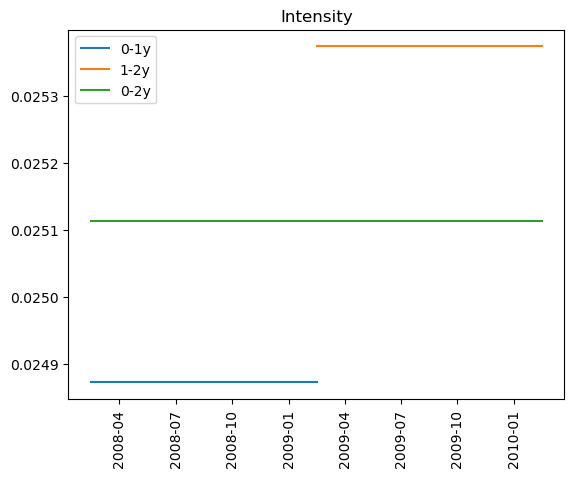

In [8]:
import matplotlib.pyplot as plt

plt.plot([today, expiry1], [h_1y, h_1y])
plt.plot([expiry1, expiry2], [h_1y2y, h_1y2y])
plt.plot([today, expiry2], [h_2y, h_2y])
plt.xticks(rotation=90)
plt.legend([f"0-{maturity1}y", f"{maturity1}-{maturity2}y", f"0-{maturity2}y"])
plt.title("Intensity")

In [9]:
# Survival probabilities
surv_prob_1y = np.exp(-h_1y * 1) 
surv_prob_2y = surv_prob_1y * np.exp(-h_1y2y * 1 )

# Defaul probabilities
default_prob_1y = 1 - surv_prob_1y
default_prob_2y = 1 - surv_prob_2y 

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.456525%
2y default probability: 4.900396%


#### Q4: Estimate the default probabilities under a shock of the mid-term creditworthiness

In [10]:
dirty_price1_shock = dirty_price1
dirty_price2_shock = 97.0

# Choosing piecewise constant intensity because it's a better approximation
# ! COMPLETE AS APPROPRIATE !
h_1y_shock=h_1y
h_1y2y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        today,
        today,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y, intensity[0]], index=[1.0, 2.0]),
        discount_factors,
        100,
    )
    - dirty_price2_shock,
    x0=0.02,
)[0]


# Survival probabilities
surv_prob_1y_shock = np.exp(-h_1y_shock * maturity1) 
surv_prob_2y_shock = np.exp(-h_1y2y_shock * maturity2)

# Defaul probabilities
default_prob_1y_shock = (1-surv_prob_1y_shock)
default_prob_2y_shock = (1-surv_prob_2y_shock)

print(f"{maturity1}y default probability: {default_prob_1y_shock:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y_shock:.6%}")

1y default probability: 2.456525%
2y default probability: 23.772882%


#### Q5: Real world default probability from the rating transition matrix

In [11]:
# rating transition matrix at 1y
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

transition_matrix_2y = transition_matrix @ transition_matrix  #@ instead of *

print(
    f"One year real world default probability: {transition_matrix.at[rating, 'Def']:.2%}"
)
print(
    f"Two year real world default probability: {transition_matrix_2y.at[rating, 'Def']:.2%}"
)

pd_real_1y = transition_matrix.at[rating, 'Def']    
pd_real_2y = transition_matrix_2y.at[rating, 'Def']   
conditional_real_default_prob_1y2y = (pd_real_2y - pd_real_1y) / (1 - pd_real_1y)  #Bayes theorem
conditional_implied_default_prob_1y2y = 1 - np.exp(-h_1y2y * 1)  #dt=1y

print(
    f"Real world conditional default probability: {conditional_real_default_prob_1y2y:.2%}"
)
print(
    f"Implied conditional default probability: {conditional_implied_default_prob_1y2y:.2%}"
)

One year real world default probability: 2.00%
Two year real world default probability: 4.71%
Real world conditional default probability: 2.77%
Implied conditional default probability: 2.51%


#### Q6: Bond portfolio priced with transition matrix
One year IG zero-coupon bond

$\bar{B}^{IG}(t,t_1)=(1-\pi_{1,3})B(t,t_1) + \pi_{1,3} B(t,t_1/2)\eta$

Two years IG zero-coupon bond

$\bar{B}^{IG}(t,t_2)=\pi_{1,1}B(t,t_1)\bar{B}^{IG}(t_1,t_2) + \pi_{1,2}B(t,t_1)\bar{B}^{HY}(t_1,t_2)+\pi_{1,3}B(t,t_1/2) \eta$

where:
- $\eta$ is the recovery
- $\bar{B}^{IG}(t_1,t_2)$ is the forward zero coupon bond IG
- $\bar{B}^{HY}(t_1,t_2)$ is the forward zero coupon bond HY

In [12]:
# Parameters
issuers_num = 100  # Number of bonds in the portfolio
maturity = 2  # Maturity in years

rating = "IG"  # Credit rating

expiry = business_date_offset(today, year_offset=maturity)

# Same matrix as before
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

recovery_rate = 0.4
face_value = 1_000_000   # of each bond
rho = [0.0, 0.25, 0.50]
mc_simulations = 1_000_000

In [13]:
# a) Portfolio MtM assuming all issuers IG

# Convert to Pandas Timestamp to enable vectorized time operations
today = pd.Timestamp(today)

# Calculate zero-coupon bond discount factors B(t, T)
df_1y = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, year_offset=1),
    discount_factors.index,
    discount_factors.values,
)

df_1_5y = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, year_offset=1, month_offset=6),
    discount_factors.index,
    discount_factors.values,
)

expiry = business_date_offset(today, year_offset=maturity)  
df_expiry = get_discount_factor_by_zero_rates_linear_interp(
    today,
    expiry,
    discount_factors.index,
    discount_factors.values,
)

df_2y_def = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, month_offset=18),  
    discount_factors.index,
    discount_factors.values,
)

df_1y_def = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, month_offset=6),  
    discount_factors.index,
    discount_factors.values,
)

# 1-year forward discount factors: B(t1, T) = B(t, T) / B(t, t1)
df_1y_fwd = df_expiry / df_1y
df_1y_1_5y_fwd = df_1_5y / df_1y

# 2-year transition matrix via dot product
transition_matrix_2y = transition_matrix @ transition_matrix #in the original code there was a mistake here, it was written transition_matrix * transition_matrix which is wrong

# 1-year transition probabilities
survival_prob_1y = transition_matrix.loc[rating, [rating, "HY"]].sum()
survival_prob_2y = transition_matrix_2y.loc[rating, [rating, "HY"]].sum()

# Calculation of usefull probabilities
pi_1 = transition_matrix.loc[rating, "IG"]      
pi_2 = transition_matrix.loc[rating, "HY"]      
pi_def_ig = transition_matrix.loc["IG", "Def"]  
pi_def_hy = transition_matrix.loc["HY", "Def"]  

# 1-year forward prices for IG and HY bonds
# Formula: P(Survival) * B(t1, t2) + P(Default) * Recovery * B(t1, t1.5)
fwd_price_ig = (1 - pi_def_ig) * df_1y_fwd + pi_def_ig * recovery_rate * df_1y_1_5y_fwd
fwd_price_hy = (1 - pi_def_hy) * df_1y_fwd + pi_def_hy * recovery_rate * df_1y_1_5y_fwd

# 2-year IG bond dirty price (MtM)
# Discounted sum of expected values: IG survival, HY downgrade, and Year 1 default
bond_mtm = (pi_1 * df_1y * fwd_price_ig) + (pi_2 * df_1y * fwd_price_hy) + (pi_def_ig * recovery_rate * df_1y_def)

# Total portfolio MtM
ptf_mtm = issuers_num * face_value * bond_mtm
print(f"Portfolio MtM: €{ptf_mtm:,.2f}")

Portfolio MtM: €90,138,743.73


In [14]:
# b) Evaluate the present value in 1 year time under various scenarios

ref_date = business_date_offset(today, year_offset=1)

# ! COMPLETE AS APPROPRIATE !
df_expiry = get_discount_factor_by_zero_rates_linear_interp(
    today,
    expiry,
    discount_factors.index,
    discount_factors.values,
) 
df_ref_date = get_discount_factor_by_zero_rates_linear_interp(
    today,
    ref_date,
    discount_factors.index,
    discount_factors.values,
)
df_2y_def = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, month_offset=18),  
    discount_factors.index,
    discount_factors.values,
)

fwd_df = df_expiry / df_ref_date          # forward discount factor B(reference_date,expiry)
fwd_df_1y_def = df_2y_def / df_ref_date   # forward discount factor B(reference_date,"avg" default date)

survival_prob_ig_1y = 1- pi_def_ig
survival_prob_hy_1y = 1- pi_def_hy

fwd_price_ig = fwd_df * survival_prob_ig_1y + recovery_rate * (1 - survival_prob_ig_1y) * fwd_df_1y_def #mistake correction: the default probability made use of the wrong survival probability, it should be survival_prob_ig_1y instead of survival_prob_hy_1y
fwd_price_hy = fwd_df * survival_prob_hy_1y + recovery_rate * (1 - survival_prob_hy_1y) * fwd_df_1y_def
fwd_price = (
    fwd_price_ig * pi_1
    + fwd_price_hy * pi_2
    + recovery_rate * transition_matrix.at[rating, "Def"] * fwd_df
)
print(fwd_price)

0.9373341394196564


In [15]:
# c) Monte Carlo simulation
# Barriers and PnL for a single IG issuer
# ! COMPLETE AS APPROPRIATE !
from scipy.stats import norm
barrier_default = norm.ppf(transition_matrix.at[rating, "Def"])

if rating == "IG":
    barrier_downgrade = norm.ppf(pi_def_ig + pi_2) 
    barrier_upgrade = np.inf # upgrade from IG is not possible
    
    loss_given_default = (recovery_rate * fwd_df_1y_def) - fwd_price
    loss_given_downgrade = fwd_price_hy - fwd_price
    loss_status_quo = fwd_price_ig - fwd_price
    loss_upgrade = 0 

elif rating == "HY":
    barrier_downgrade = -np.inf # downgrade from HY is not possible
    barrier_upgrade = norm.ppf(pi_2 + pi_def_hy)

    loss_given_default = (recovery_rate * fwd_df_1y_def) - fwd_price
    loss_given_downgrade = 0
    loss_status_quo = fwd_price_hy - fwd_price
    loss_upgrade = fwd_price_ig - fwd_price

In [16]:
# 3 correlation scenarios
# to have the same result at each run, fix the seed
y = np.random.normal(size=(mc_simulations, 1))
eps = np.random.normal(size=(mc_simulations, issuers_num))

# Adding correlation
r = rho[0] # repeat with rho[1] and rho[2] or try to do all together: array can have n-dimensions
v = np.sqrt(r) * y + np.sqrt(1 - r) * eps


In [17]:
# count of defaults, downgrades, upgrades in each simulation...
# ! COMPLETE AS APPROPRIATE !
defaults = (v < barrier_default).sum(axis=1)
downgrades = ((barrier_default <= v) & (v < barrier_downgrade)).sum(axis=1)
status_quo = ((barrier_downgrade <= v) & (v < barrier_upgrade)).sum(axis=1)
upgrades = (v >= barrier_upgrade).sum(axis=1)

print(f"Average defaults: {defaults.mean()}")
print(f"Average downgrades: {downgrades.mean()}")
print(f"Average status quo: {status_quo.mean()}")
print(f"Average upgrades: {upgrades.mean()}")


Average defaults: 2.001003
Average downgrades: 24.996057
Average status quo: 73.00294
Average upgrades: 0.0


In [18]:
# Marginal distributions (check)
prob_default = defaults.mean() / issuers_num
prob_downgrade = downgrades.mean() / issuers_num
prob_status_quo = status_quo.mean() / issuers_num
prob_upgrades = upgrades.mean() / issuers_num

In [19]:
# Evaluating the one-year 99% VaR by taking into account defaults only/defaults and rating changes:
defaults_only = True

if defaults_only:
    scenario = defaults * loss_given_default
else:
    scenario = defaults * loss_given_default + downgrades * loss_given_downgrade # ! COMPLETE AS APPROPRIATE ! 

# Calculation of VaR and Expected Loss have a minus in front of expressions because losses are negative
VaR = -np.quantile(scenario, 0.01) * face_value # Mistake Correction: the quantile was at 0.001 instead of 0.01
expected_loss = -scenario.mean() * face_value
display(scenario)
print(f"Expected loss: {expected_loss:,.2f}€")
print(f"VaR: {VaR:,.2f}€")

array([-1.08827915, -0.54413958, -0.        , ..., -0.54413958,
       -0.54413958, -1.08827915], shape=(1000000,))

Expected loss: 1,088,824.93€
VaR: 3,264,837.46€


Text(0.5, 1.0, 'Loss distribution')

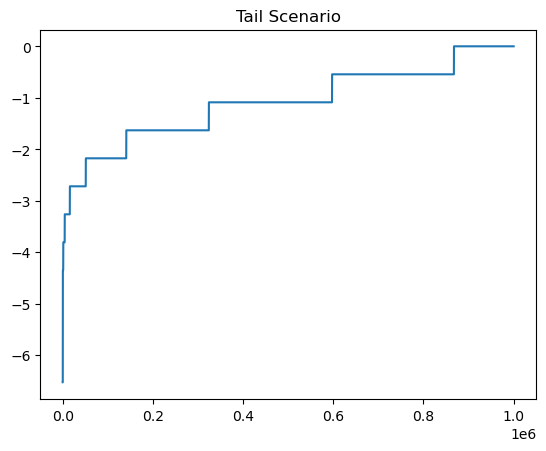

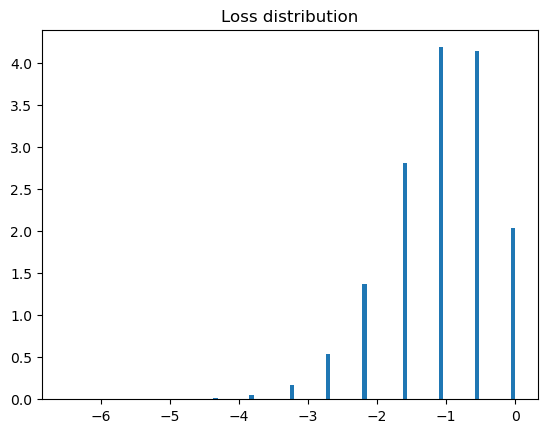

In [20]:
# Plot
import matplotlib.pyplot as plt
scenario.sort()
plt.figure()
plt.plot(scenario)
plt.title("Tail Scenario")

plt.figure()
plt.hist(scenario, bins=100, density=True)
plt.title("Loss distribution")